===== TRAINING STARTED =====
Epoch 500 | Loss=4.811e+00 | x0=0.381 | A=1.554
Epoch 1000 | Loss=7.744e-01 | x0=0.394 | A=2.317
Epoch 1500 | Loss=5.481e-01 | x0=0.395 | A=2.841
Epoch 2000 | Loss=4.094e-01 | x0=0.396 | A=3.293


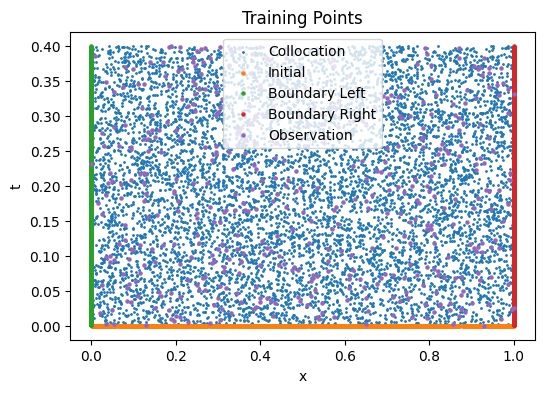

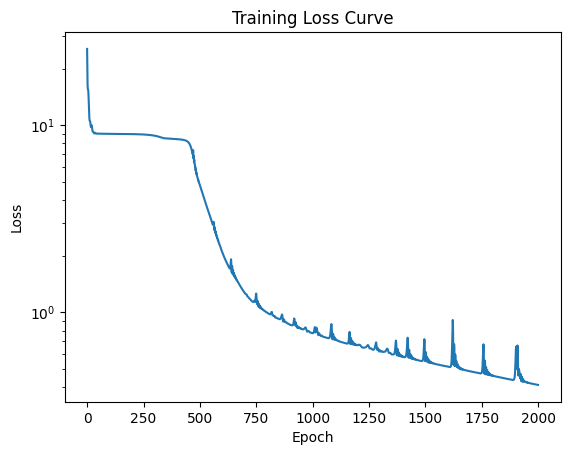

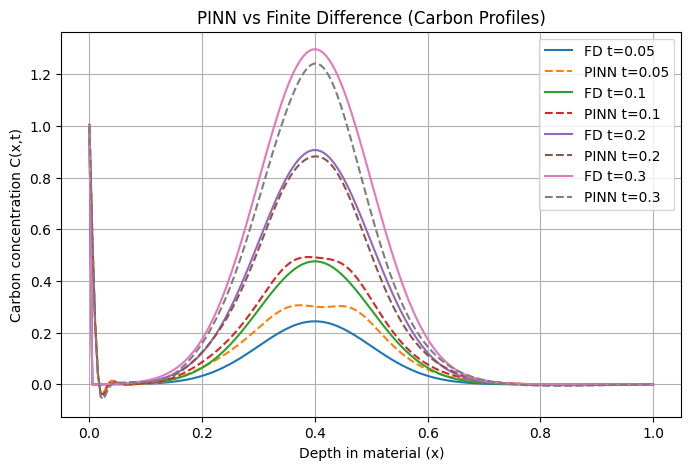

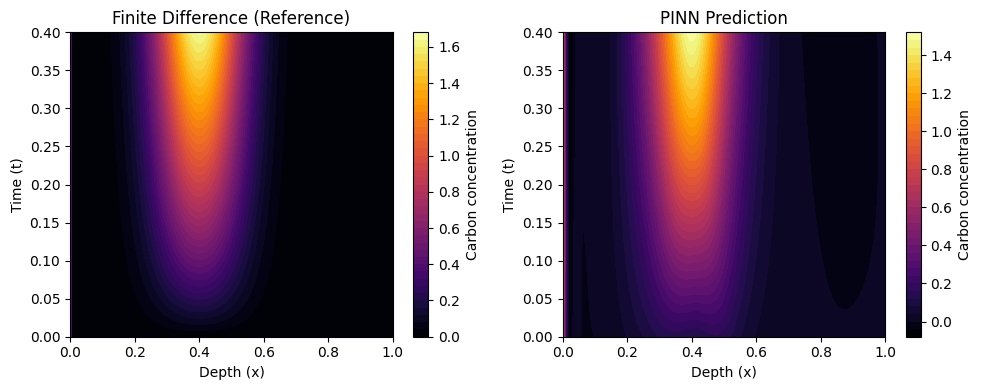

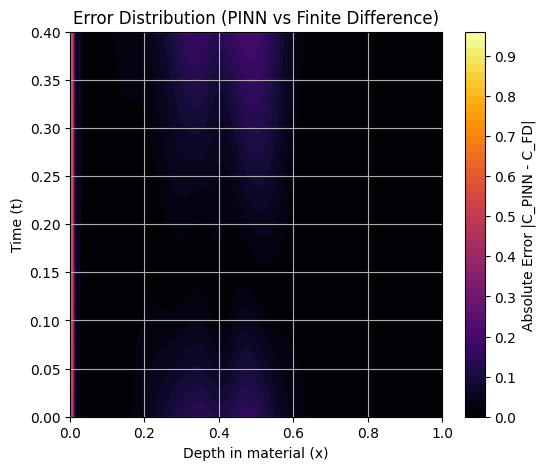

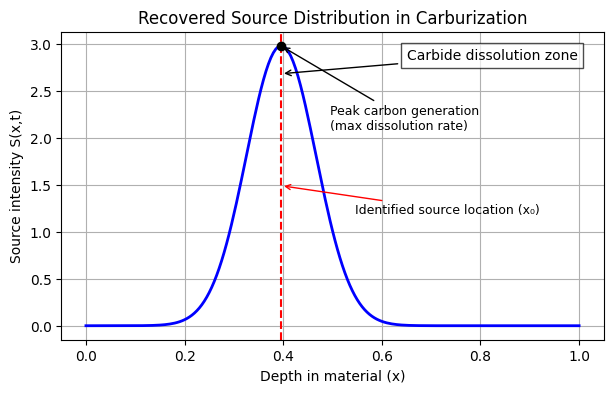

In [6]:
# =============================================================
# FINAL CODE (WITH ALL PLOTS + LEGENDS + TRAINING CURVE)
# =============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, optimizers

# ================= USER CONTROL =================
EPOCHS = 2000   # <-- change anytime
Nf = 8000

# ================= PHYSICS =================
L = 1.0 ##normalized domain
t_final = 0.4 ##normalized time

D0, Ea, R = 2e-5, 142000, 8.314 ##activation energy for carbon in austenite

def T_furnace(t):
    return 1173 + 50*tf.sin(0.5*t)

def D(t):
    return D0 * tf.exp(-Ea/(R*T_furnace(t)))

# ================= FD SOLVER =================
def solve_fd(Nx=201, Nt=801):
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, t_final, Nt)
    dx = x[1]-x[0]; dt = t[1]-t[0]
    c = np.zeros((Nt, Nx))

    for n in range(Nt-1):
        s = 5.0*np.exp(-((x-0.4)**2)/0.02)*np.exp(-t[n]) ##source location defined here for prediction and 
        dcxx = np.zeros_like(x)
        dcxx[1:-1] = (c[n,2:]-2*c[n,1:-1]+c[n,:-2])/(dx**2)
        D_t = D(tf.constant([[t[n]]], dtype=tf.float32)).numpy()[0][0]
        c[n+1,1:-1] = c[n,1:-1] + dt*(D_t*dcxx[1:-1] + s[1:-1])
        c[n+1,0] = 1.0
        c[n+1,-1] = 0.0
    return x,t,c

x_ref,t_ref,c_ref = solve_fd()

# ================= PINN =================
## N are the number of points for the fucntion 
def build_pinn():
    model = tf.keras.Sequential([layers.Input((2,))])
    for _ in range(4):
        model.add(layers.Dense(64, activation='tanh'))
    model.add(layers.Dense(1))
    return model

pinn = build_pinn()

# ================= DATA =================
x_f = np.random.rand(Nf,1).astype(np.float32)
t_f = np.random.rand(Nf,1).astype(np.float32)*t_final
X_f = tf.constant(np.hstack([x_f, t_f]))

Ni = 1000 ##initial condition (IC)
x_i = np.random.rand(Ni,1).astype(np.float32)
t_i = np.zeros((Ni,1), np.float32)
X_i = tf.constant(np.hstack([x_i, t_i]))
C_i = tf.zeros((Ni,1), tf.float32)

Nb = 1000 ##boundary conditions(BC)
t_b = np.random.rand(Nb,1).astype(np.float32)*t_final
X_bL = tf.constant(np.hstack([np.zeros((Nb,1), np.float32), t_b]))
X_bR = tf.constant(np.hstack([np.ones((Nb,1), np.float32), t_b]))
C_bL = tf.ones((Nb,1), tf.float32)
C_bR = tf.zeros((Nb,1), tf.float32)
##bl= left boundary
##br = right boundary (deep interior)

# Observation data
N_data = 500 ##it is sampled fromt the Fd solution 
XX, TT = np.meshgrid(x_ref, t_ref)
XT_all = np.hstack([XX.reshape(-1,1), TT.reshape(-1,1)])
C_all = c_ref.reshape(-1,1)
idx = np.random.choice(len(XT_all), size=N_data, replace=False) ##randomly picking 500 points from the FDE solution
X_obs = tf.constant(XT_all[idx].astype(np.float32))
C_obs = tf.constant(C_all[idx].astype(np.float32))

# ================= INVERSE =================
x0_unb = tf.Variable(0.0, dtype=tf.float32) ##source location unknown
A_unb  = tf.Variable(1.0, dtype=tf.float32) ##source strength unknown
sigma_x = 0.1 ## spread of the source 

def mapped_params():
    return tf.sigmoid(x0_unb), tf.nn.softplus(A_unb) ##sigmoid used because x belongs to [0,1] only. softplus converts any number positive.
##the spatial domain was already normalized to L=1.0

def source_trainable(x, t):
    x0, A = mapped_params()
    return A * tf.exp(-((x - x0)**2)/(sigma_x**2)) * tf.exp(-t) ## gaussian curved assumed for the source, it decays with time!!

# ================= PDE =================
mse = lambda a,b: tf.reduce_mean(tf.square(a-b))

def pde_residual(X): ##solving the pde residual
    x = X[:,0:1]; t = X[:,1:2]
    with tf.GradientTape(persistent=True) as g1:
        g1.watch([x,t])
        with tf.GradientTape(persistent=True) as g2:
            g2.watch([x,t]) ##inner and outer derivatives.
            c = pinn(tf.concat([x,t], 1))
        c_x = g2.gradient(c, x) ##(dell C / dell x)
        c_t = g2.gradient(c, t)##(dell C / dell t)
    c_xx = g1.gradient(c_x, x)
    return c_t - D(t)*c_xx - source_trainable(x,t) ## this is the final PDE expression !

# ================= LOSS =================
w_pde, w_ic, w_L, w_R, w_data = 1.0, 10.0, 10.0, 10.0, 50.0 ##weightage to each residual

def compute_loss():
    return (w_pde*mse(pde_residual(X_f), tf.zeros((Nf,1))) +  ## PDE residual
            w_ic*mse(pinn(X_i), C_i) + ##initial condition residual
            w_L*mse(pinn(X_bL), C_bL) + ##left and right boundary loss residual
            w_R*mse(pinn(X_bR), C_bR) +
            w_data*mse(pinn(X_obs), C_obs)) ##(C_pred - C_obs) squared

# ================= TRAIN =================
optimizer = optimizers.Adam(1e-3)
train_vars = pinn.trainable_variables + [x0_unb, A_unb]
loss_hist = []

print("===== TRAINING STARTED =====")
for ep in range(1, EPOCHS+1):
    with tf.GradientTape() as tape:
        loss = compute_loss() ##computes total loss
    grads = tape.gradient(loss, train_vars) ##computes gradients, these tell parameters how to reduce loss/how to improve
    optimizer.apply_gradients(zip(grads, train_vars)) ##updates the parameters
    loss_hist.append(loss.numpy()) ##stores loss

    if ep % 500 == 0: ##prints progress every 500 iterations
        x0_val, A_val = mapped_params()
        print(f"Epoch {ep} | Loss={loss.numpy():.3e} | x0={float(x0_val.numpy()):.3f} | A={float(A_val.numpy()):.3f}") ##repeat
## goal of training is such that the loss is 0 and PDE is satisfied

# ================= TRAINING POINTS =================
plt.figure(figsize=(6,4))
plt.scatter(x_f, t_f, s=1, label="Collocation")
plt.scatter(x_i, t_i, s=5, label="Initial")
plt.scatter(np.zeros_like(t_b), t_b, s=5, label="Boundary Left")
plt.scatter(np.ones_like(t_b), t_b, s=5, label="Boundary Right")
plt.scatter(X_obs[:,0], X_obs[:,1], s=5, label="Observation")
plt.legend()
plt.title("Training Points")
plt.xlabel("x"); plt.ylabel("t")
plt.show()

# ================= LOSS CURVE =================
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ================= MULTI-TIME =================
plt.figure(figsize=(8,5))
times = [0.05,0.1,0.2,0.3]

for t_val in times:
    x_plot = x_ref
    t_plot = np.ones_like(x_plot)*t_val
    XT = tf.constant(np.vstack([x_plot, t_plot]).T.astype(np.float32))
    C_pred = pinn(XT).numpy().flatten()

    idx_t = np.argmin(np.abs(t_ref - t_val))
    C_fd = c_ref[idx_t]

    plt.plot(x_plot, C_fd, label=f"FD t={t_val}")
    plt.plot(x_plot, C_pred, '--', label=f"PINN t={t_val}")

#  Added labels
plt.xlabel("Depth in material (x)")
plt.ylabel("Carbon concentration C(x,t)")

plt.legend()
plt.title("PINN vs Finite Difference (Carbon Profiles)")
plt.grid()
plt.show()


# ================= HEATMAP =================
Xg,Tg = np.meshgrid(x_ref,t_ref)
XT = tf.constant(np.hstack([Xg.reshape(-1,1),Tg.reshape(-1,1)]).astype(np.float32))
C_pred_grid = pinn(XT).numpy().reshape(len(t_ref),len(x_ref))

plt.figure(figsize=(10,4))

# ---- FD ----
plt.subplot(1,2,1)
cont1 = plt.contourf(x_ref, t_ref, c_ref, 50, cmap='inferno')
plt.title("Finite Difference (Reference)")
plt.xlabel("Depth (x)")
plt.ylabel("Time (t)")
plt.colorbar(cont1, label="Carbon concentration")

# ---- PINN ----
plt.subplot(1,2,2)
cont2 = plt.contourf(x_ref, t_ref, C_pred_grid, 50, cmap='inferno')
plt.title("PINN Prediction")
plt.xlabel("Depth (x)")
plt.ylabel("Time (t)")
plt.colorbar(cont2, label="Carbon concentration")

plt.tight_layout()
plt.show()

# ================= ERROR =================
plt.figure(figsize=(6,5))

err = np.abs(C_pred_grid - c_ref)
cont = plt.contourf(x_ref, t_ref, err, 50, cmap='inferno')

#  Axis labels
plt.xlabel("Depth in material (x)")
plt.ylabel("Time (t)")

#  Colorbar with label
cbar = plt.colorbar(cont)
cbar.set_label("Absolute Error |C_PINN - C_FD|")

#  Title + grid
plt.title("Error Distribution (PINN vs Finite Difference)")
plt.grid()

plt.show()

# ================= SOURCE (ANNOTATED FOR PRESENTATION) =================

x_plot = x_ref.reshape(-1,1)
t_plot = np.ones_like(x_plot)*0.1

x_tf = tf.constant(x_plot, dtype=tf.float32)
t_tf = tf.constant(t_plot, dtype=tf.float32)

source_pred = source_trainable(x_tf, t_tf).numpy()

# Get learned parameters
x0_val, A_val = mapped_params()
x0_val = float(x0_val.numpy())

plt.figure(figsize=(7,4))

# Main curve
plt.plot(x_plot, source_pred, color='blue', linewidth=2)

# Mark source location
plt.axvline(x=x0_val, color='red', linestyle='--')

# Peak point
peak_idx = np.argmax(source_pred)
x_peak = x_plot[peak_idx][0]
y_peak = source_pred[peak_idx][0]

plt.scatter(x_peak, y_peak, color='black', zorder=5)

# ===== ANNOTATIONS =====

# Peak annotation
plt.annotate("Peak carbon generation\n(max dissolution rate)",
             xy=(x_peak, y_peak),
             xytext=(x_peak+0.1, y_peak*0.7),
             arrowprops=dict(arrowstyle="->", color='black'),
             fontsize=9)

# Source location annotation
plt.annotate("Identified source location (x₀)",
             xy=(x0_val, y_peak*0.5),
             xytext=(x0_val+0.15, y_peak*0.4),
             arrowprops=dict(arrowstyle="->", color='red'),
             fontsize=9)

# Region annotation
plt.annotate("Carbide dissolution zone",
             xy=(x0_val, y_peak*0.9),
             xytext=(0.65, y_peak*0.95),
             arrowprops=dict(arrowstyle="->"),
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# Axis labels
plt.xlabel("Depth in material (x)")
plt.ylabel("Source intensity S(x,t)")

# Title
plt.title("Recovered Source Distribution in Carburization")

plt.grid()
plt.show()
